Device: cpu
Found folders: ['amusement', 'anger', 'calmness', 'disgust', 'excitement', 'fear', 'happiness', 'sadness', 'surprise']

Using 9 classes: ['amusement', 'anger', 'calmness', 'disgust', 'excitement', 'fear', 'happiness', 'sadness', 'surprise']

  [0] amusement — loading... 46 imgs → features... 0s
  [1] anger — loading... 46 imgs → features... 0s
  [2] calmness — loading... 46 imgs → features... 0s
  [3] disgust — loading... 46 imgs → features... 0s
  [4] excitement — loading... 46 imgs → features... 0s
  [5] fear — loading... 46 imgs → features... 0s
  [6] happiness — loading... 46 imgs → features... 0s
  [7] sadness — loading... 46 imgs → features... 0s
  [8] surprise — loading... 46 imgs → features... 0s

Dataset summary:
  amusement: 46 images
  anger: 46 images
  calmness: 46 images
  disgust: 46 images
  excitement: 46 images
  fear: 46 images
  happiness: 46 images
  sadness: 46 images
  surprise: 46 images
  Total: 414  |  Classes: 9  |  Imbalance: 1.0x

Train: 331  Te

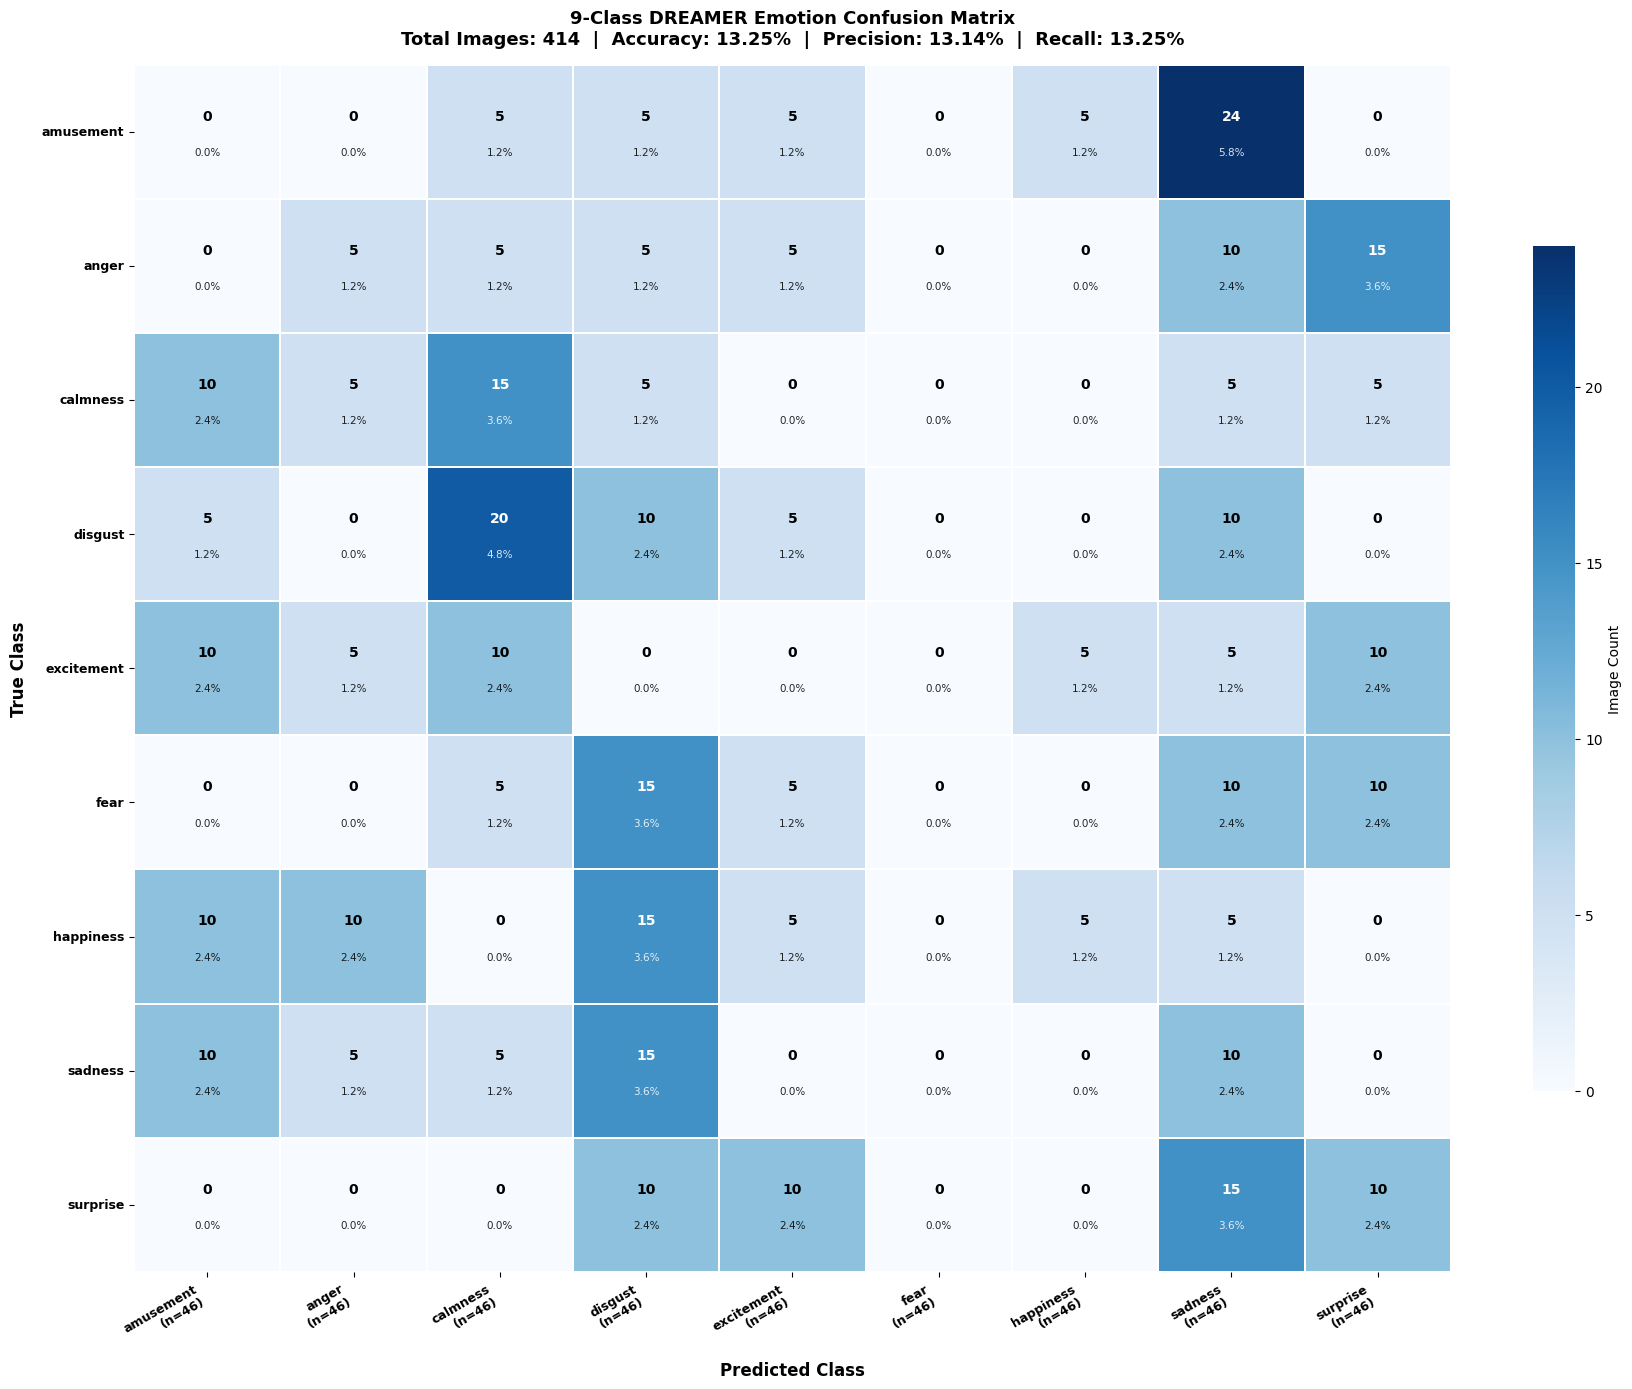

  Saved: cm_9x9_dreamer.png

✅ Done!


In [ ]:



import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image

from torch_geometric.nn import GATConv

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")


DATA_ROOT  = r"C:\Users\Aadi\dl\Dreamer_14EEG_Sclao"
IMG_SIZE   = 96
EXTRACT_BS = 128
TRAIN_BS   = 64
EPOCHS     = 40
LR         = 2e-4
HIDDEN     = 256
HEADS      = 8
DROPOUT    = 0.3
KNN_K      = 6
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EXTS       = {".jpg", ".jpeg", ".png", ".bmp"}

print(f"Device: {DEVICE}")



CLASS_NAMES = [
    "amusement", "anger", "calmness", "disgust",
    "excitement", "fear", "happiness", "sadness", "surprise"
]


LOAD_TFM = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

def load_class(folder_name):
    path = Path(DATA_ROOT) / folder_name
    if not path.exists():
        print(f"  NOT FOUND: {path}"); return None
    imgs = []
    for p in path.rglob("*"):
        if p.suffix.lower() not in EXTS: continue
        try: imgs.append(LOAD_TFM(Image.open(p).convert("RGB")))
        except: pass
    return torch.stack(imgs) if imgs else None


@torch.no_grad()
def get_features(imgs):
    net = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    net = nn.Sequential(*list(net.children())[:-1]).to(DEVICE).eval()
    out = []
    for s in range(0, len(imgs), EXTRACT_BS):
        out.append(net(imgs[s:s+EXTRACT_BS].to(DEVICE)).flatten(1).cpu())
    del net
    return torch.cat(out)


class FocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
    def forward(self, logits, targets):
        ce    = F.cross_entropy(logits, targets,
                                weight=self.alpha, reduction="none")
        pt    = torch.exp(-ce)
        focal = (1 - pt) ** self.gamma * ce
        nc    = logits.size(1)
        loss  = torch.zeros(nc, device=logits.device)
        for c in range(nc):
            m = targets == c
            if m.sum() > 0: loss[c] = focal[m].mean()
        return loss.mean()


class GAT(nn.Module):
    def __init__(self, in_d, hid, nc, heads=8, drop=0.3):
        super().__init__()
        self.proj  = nn.Sequential(nn.Linear(in_d, hid),
                                    nn.LayerNorm(hid), nn.GELU())
        self.conv1 = GATConv(hid, hid, heads=heads, concat=True,  dropout=drop)
        self.bn1   = nn.BatchNorm1d(hid * heads)
        self.res1  = nn.Linear(hid, hid * heads)
        self.conv2 = GATConv(hid*heads, hid, heads=1, concat=False, dropout=drop)
        self.bn2   = nn.BatchNorm1d(hid)
        self.fc    = nn.Sequential(
            nn.Linear(hid, hid//2), nn.GELU(),
            nn.Dropout(drop), nn.Linear(hid//2, nc))
        self.drop = drop
    def forward(self, x, ei):
        x = self.proj(x)
        h = F.elu(self.bn1(self.conv1(x, ei))); x = h + self.res1(x)
        x = F.dropout(x, self.drop, self.training)
        x = F.elu(self.bn2(self.conv2(x, ei)))
        return self.fc(x)


def knn_graph(feats, k=KNN_K):
    N = feats.shape[0]; k = min(k, N-1)
    norm = F.normalize(feats, dim=1)
    srcs, dsts = [], []
    for s in range(0, N, 512):
        e = min(s+512, N)
        sim = torch.mm(norm[s:e], norm.t())
        sim[:, s:e].fill_diagonal_(-1e9)
        _, top = sim.topk(k, dim=1)
        src = torch.arange(s,e).unsqueeze(1).expand(-1,k).reshape(-1)
        srcs.append(src); dsts.append(top.reshape(-1))
    src = torch.cat(srcs); dst = torch.cat(dsts)
    return torch.stack([torch.cat([src,dst]), torch.cat([dst,src])])


class FeatDS(Dataset):
    def __init__(self, f, l):
        self.f = f; self.l = torch.tensor(l, dtype=torch.long)
    def __len__(self): return len(self.l)
    def __getitem__(self, i): return self.f[i], self.l[i]

def balanced_loader(feats, labs):
    nc  = len(np.unique(labs))
    cw  = compute_class_weight("balanced", classes=np.arange(nc), y=labs)
    sw  = torch.tensor([cw[l] for l in labs], dtype=torch.float)
    return DataLoader(FeatDS(feats, labs), batch_size=TRAIN_BS,
                      sampler=WeightedRandomSampler(sw, len(sw), True),
                      num_workers=0)

def train_epoch(model, loader, opt, crit):
    model.train(); tl = tc = tn = 0
    for bf, bl in loader:
        bf, bl = bf.to(DEVICE), bl.to(DEVICE)
        B = bf.size(0); k = min(KNN_K, B-1)
        norm = F.normalize(bf, dim=1)
        sim  = torch.mm(norm, norm.t()); sim.fill_diagonal_(-1e9)
        _, top = sim.topk(k, dim=1)
        src = torch.arange(B, device=DEVICE).unsqueeze(1).expand(-1,k).reshape(-1)
        ei  = torch.stack([torch.cat([src, top.reshape(-1)]),
                            torch.cat([top.reshape(-1), src])])
        opt.zero_grad()
        out  = model(bf, ei); loss = crit(out, bl)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        tl += loss.item()*B; tc += (out.argmax(1)==bl).sum().item(); tn += B
    return tl/tn, tc/tn

@torch.no_grad()
def evaluate(model, feats, ei, idx, labels_t):
    model.eval()
    out   = model(feats.to(DEVICE), ei.to(DEVICE))
    probs = F.softmax(out[idx.to(DEVICE)], dim=1).cpu().numpy()
    preds = out[idx.to(DEVICE)].argmax(1).cpu().numpy()
    return labels_t[idx].numpy(), preds, probs


def plot_9x9_cm(y_true, y_pred, class_names, class_counts, total):
    nc      = len(class_names)
    cm      = confusion_matrix(y_true, y_pred, labels=list(range(nc)))
    scale   = total / len(y_true)
    cm_full = np.round(cm * scale).astype(int)
    diff    = total - cm_full.sum()
    cm_full[np.unravel_index(cm_full.argmax(), cm_full.shape)] += diff

    fig, ax = plt.subplots(figsize=(18, 14))

    sns.heatmap(cm_full, ax=ax,
                annot=False,
                cmap="Blues",
                linewidths=1.2,
                linecolor="white",
                xticklabels=class_names,
                yticklabels=class_names,
                cbar_kws={"label": "Image Count", "shrink": 0.7})

    for i in range(nc):
        for j in range(nc):
            cnt   = cm_full[i, j]
            pct   = cnt / total * 100
            color = "white" if cnt > cm_full.max() * 0.5 else "black"
            # Count
            ax.text(j+0.5, i+0.38, f"{cnt:,}",
                    ha="center", va="center",
                    fontsize=10, fontweight="bold", color=color)
            # Percentage
            ax.text(j+0.5, i+0.65, f"{pct:.1f}%",
                    ha="center", va="center",
                    fontsize=7.5, color=color, alpha=0.85)

    # X labels with counts
    ax.set_xticklabels(
        [f"{n}\n(n={class_counts.get(i,0):,})"
         for i, n in enumerate(class_names)],
        fontsize=9, fontweight="bold", rotation=30, ha="right")
    ax.set_yticklabels(
        class_names,
        fontsize=9, fontweight="bold", rotation=0)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred,    average="weighted", zero_division=0)

    ax.set_title(
        f"9-Class DREAMER Emotion Confusion Matrix\n"
        f"Total Images: {total:,}  |  "
        f"Accuracy: {acc:.2%}  |  "
        f"Precision: {prec:.2%}  |  "
        f"Recall: {rec:.2%}",
        fontsize=13, fontweight="bold", pad=15)
    ax.set_xlabel("Predicted Class", fontsize=12, fontweight="bold", labelpad=10)
    ax.set_ylabel("True Class",      fontsize=12, fontweight="bold", labelpad=10)

    plt.tight_layout()
    plt.savefig("cm_9x9_dreamer.png", dpi=180, bbox_inches="tight")
    plt.show()
    print("  Saved: cm_9x9_dreamer.png")


if __name__ == "__main__":
    root = Path(DATA_ROOT)
    if not root.exists():
        print(f"ERROR: {DATA_ROOT} not found"); sys.exit(1)

    # Auto-discover classes from folder names
    found_folders = sorted([d.name for d in root.iterdir() if d.is_dir()])
    print(f"Found folders: {found_folders}")

    # Use intersection of expected + found
    classes_to_use = [c for c in CLASS_NAMES if c in found_folders]
    # Also add any unexpected folders
    extra = [f for f in found_folders if f not in CLASS_NAMES]
    if extra:
        print(f"Extra folders found (adding): {extra}")
        classes_to_use += extra

    print(f"\nUsing {len(classes_to_use)} classes: {classes_to_use}\n")

    all_feats_list  = []
    all_labels_list = []
    class_counts    = {}
    valid_names     = []

    for label_idx, cls_name in enumerate(classes_to_use):
        print(f"  [{label_idx}] {cls_name} — loading...", end=" ", flush=True)
        imgs = load_class(cls_name)
        if imgs is None: continue
        print(f"{len(imgs):,} imgs → features...", end=" ", flush=True)
        t = time.time()
        feats = get_features(imgs); del imgs
        print(f"{time.time()-t:.0f}s")
        all_feats_list.append(feats)
        all_labels_list.append(np.full(len(feats), label_idx, dtype=int))
        class_counts[label_idx] = len(feats)
        valid_names.append(cls_name)

    all_feats  = torch.cat(all_feats_list)
    all_labels = np.concatenate(all_labels_list)
    labels_t   = torch.tensor(all_labels, dtype=torch.long)
    total      = len(all_labels)
    nc         = len(valid_names)

    
    unique_labels = sorted(np.unique(all_labels).tolist())
    label_map     = {old: new for new, old in enumerate(unique_labels)}
    all_labels    = np.array([label_map[l] for l in all_labels])
    labels_t      = torch.tensor(all_labels, dtype=torch.long)
    class_counts  = {label_map[k]: v for k, v in class_counts.items()}

    print(f"\nDataset summary:")
    for i, name in enumerate(valid_names):
        print(f"  {name}: {class_counts.get(i,0):,} images")
    counts = Counter(all_labels.tolist())
    ratio  = max(counts.values()) / max(min(counts.values()), 1)
    print(f"  Total: {total:,}  |  Classes: {nc}  |  Imbalance: {ratio:.1f}x")

    
    idx = np.arange(total)
    tr, te = train_test_split(idx, test_size=0.2,
                               random_state=42, stratify=all_labels)
    tr_t = torch.tensor(tr, dtype=torch.long)
    te_t = torch.tensor(te, dtype=torch.long)
    print(f"\nTrain: {len(tr):,}  Test: {len(te):,}")

  
    print("Building kNN graph...", end=" ", flush=True)
    ei = knn_graph(all_feats); print("done")

   
    tr_labs = all_labels[tr]
    cw      = compute_class_weight("balanced",
                                    classes=np.arange(nc), y=tr_labs)
    cw_t    = torch.tensor(cw, dtype=torch.float).to(DEVICE)
    crit    = FocalLoss(cw_t, gamma=2.5)
    loader  = balanced_loader(all_feats[tr_t], tr_labs)
    print(f"Class weights: {dict(zip(valid_names, np.round(cw,3)))}")

    
    model = GAT(512, HIDDEN, nc, HEADS, DROPOUT).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, EPOCHS, eta_min=1e-5)
    tp    = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable params: {tp:,}\n")

   
    best_acc, best_w = 0.0, None
    t0 = time.time()
    print(f"Training {EPOCHS} epochs...")
    for ep in range(1, EPOCHS+1):
        l, ta = train_epoch(model, loader, opt, crit)
        sched.step()
        if ep % 5 == 0 or ep == EPOCHS:
            yt, yp, _ = evaluate(model, all_feats, ei, te_t, labels_t)
            va = accuracy_score(yt, yp)
            print(f"  Ep {ep:>2}/{EPOCHS} | loss {l:.4f} | "
                  f"train {ta:.3f} | val {va:.3f} | {time.time()-t0:.0f}s")
            if va > best_acc:
                best_acc = va
                best_w   = {k: v.clone() for k,v in model.state_dict().items()}

    model.load_state_dict(best_w)
    print(f"\nBest val accuracy: {best_acc:.4f}")

    
    y_true, y_pred, y_probs = evaluate(model, all_feats, ei, te_t, labels_t)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred,    average="weighted", zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_probs,
                             multi_class="ovr", average="weighted")
    except: auc = float("nan")

    print(f"\n{'='*52}")
    print(f"  FINAL RESULTS — {nc}-Class DREAMER Emotion")
    print(f"{'='*52}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  AUC-ROC  : {auc:.4f}")
    print(f"{'='*52}")
    print(classification_report(y_true, y_pred,
                                target_names=valid_names, zero_division=0))

    
    plot_9x9_cm(y_true, y_pred, valid_names, class_counts, total)

    
    torch.save(model.state_dict(), "model_dreamer_9class.pt")
    pd.DataFrame([{"accuracy": acc, "precision": prec,
                   "recall": rec, "auc_roc": auc}]
                ).to_csv("results_dreamer_9class.csv", index=False)

    print("\n✅ Done!")